# E-commerce Customer Analytics

## Project Overview

This project analyses e-commerce customer behaviour and purchasing patterns using Python and data analytics techniques.

The project combines transactional/customer data analysis with user journey insights from a demo e-commerce website instrumented with Contentsquare.

### Objectives

- Analyse customer purchasing behaviour
- Identify sales and revenue trends
- Compare product categories and customer segments
- Analyse the impact of discounts and payment methods
- Explore purchasing frequency and customer characteristics
- Identify patterns that could support business decision-making
- Compare transactional insights with website journey behaviour captured through Contentsquare

### Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook
- Contentsquare
- GitHub

In [2]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Visualisation settings
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
df = pd.read_csv("eCommerce_Project/ecommerce_dataset_updated.csv")

In [6]:
# Check the size of the dataset

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 3660
Columns: 8


In [7]:
# Inspect the dataset
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Column names:
['User_ID', 'Product_ID', 'Category', 'Price (Rs.)', 'Discount (%)', 'Final_Price(Rs.)', 'Payment_Method', 'Purchase_Date']

Data types:
User_ID              object
Product_ID           object
Category             object
Price (Rs.)         float64
Discount (%)          int64
Final_Price(Rs.)    float64
Payment_Method       object
Purchase_Date        object
dtype: object

First 5 rows:


,User_ID,Product_ID,Category,Price (Rs.),Discount (%),Final_Price(Rs.),Payment_Method,Purchase_Date
0,337c166f,f414122f-e,Sports,36.53,15,31.05,Net Banking,12-11-2024
1,d38a19bf,fde50f9c-5,Clothing,232.79,20,186.23,Net Banking,09-02-2024
2,d7f5f0b0,0d96fc90-3,Sports,317.02,25,237.76,Credit Card,01-09-2024
3,395d4994,964fc44b-d,Toys,173.19,25,129.89,UPI,01-04-2024
4,a83c145c,d70e2fc6-e,Beauty,244.80,20,195.84,Net Banking,27-09-2024


In [8]:
# Check for missing values and duplicate records

print("Missing values:")
display(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:


User_ID             0
Product_ID          0
Category            0
Price (Rs.)         0
Discount (%)        0
Final_Price(Rs.)    0
Payment_Method      0
Purchase_Date       0
dtype: int64


Duplicate rows:
0


In [9]:
# Convert Purchase_Date to datetime format

df["Purchase_Date"] = pd.to_datetime(
    df["Purchase_Date"],
    dayfirst=True
)

print("Purchase_Date converted successfully.")
print(df["Purchase_Date"].dtype)

Purchase_Date converted successfully.
datetime64[ns]


In [10]:
# Understand the numerical data and purchase period

print("Purchase period:")
print("Start:", df["Purchase_Date"].min().date())
print("End:", df["Purchase_Date"].max().date())

print("\nNumerical summary:")
display(df[["Price (Rs.)", "Discount (%)", "Final_Price(Rs.)"]].describe())

Purchase period:
Start: 2024-01-01
End: 2024-11-21

Numerical summary:


,Price (Rs.),Discount (%),Final_Price(Rs.)
count,3660.000000,3660.000000,3660.000000
mean,254.800675,18.825137,206.906579
std,141.682621,14.731338,122.687844
min,10.090000,0.000000,5.890000
25%,134.012500,5.000000,104.512500
50%,253.845000,15.000000,199.185000
75%,377.595000,25.000000,304.117500
max,499.960000,50.000000,496.820000


In [11]:
# Analyse categorical variables

print("Unique users:", df["User_ID"].nunique())
print("Unique products:", df["Product_ID"].nunique())

print("\nProduct categories:")
display(df["Category"].value_counts())

print("\nPayment methods:")
display(df["Payment_Method"].value_counts())

Unique users: 3660
Unique products: 3660

Product categories:


Home & Kitchen    549
Books             534
Clothing          531
Toys              523
Sports            520
Beauty            505
Electronics       498
Name: Category, dtype: int64


Payment methods:


Credit Card         760
UPI                 757
Debit Card          731
Net Banking         716
Cash on Delivery    696
Name: Payment_Method, dtype: int64

In [12]:
# Revenue and spending by product category

category_analysis = df.groupby("Category").agg(
    Purchases=("Product_ID", "count"),
    Total_Revenue=("Final_Price(Rs.)", "sum"),
    Average_Purchase=("Final_Price(Rs.)", "mean")
).sort_values("Total_Revenue", ascending=False)

display(category_analysis)

,Purchases,Total_Revenue,Average_Purchase
Category,,,
Clothing,531,115314.84,217.165424
Books,534,111149.35,208.144850
Home & Kitchen,549,110328.08,200.961894
Sports,520,108518.79,208.689981
Toys,523,107289.69,205.142811
Beauty,505,104215.10,206.366535
Electronics,498,100462.23,201.731386


In [13]:
payment_analysis = df.groupby("Payment_Method").agg(
    Purchases=("Product_ID", "count"),
    Total_Revenue=("Final_Price(Rs.)", "sum"),
    Average_Purchase=("Final_Price(Rs.)", "mean")
).sort_values("Total_Revenue", ascending=False)

display(payment_analysis)

,Purchases,Total_Revenue,Average_Purchase
Payment_Method,,,
Credit Card,760,156018.02,205.286868
UPI,757,154684.81,204.339247
Debit Card,731,153362.26,209.797893
Net Banking,716,146804.40,205.034078
Cash on Delivery,696,146408.59,210.357170


In [14]:
# Monthly revenue analysis

df["Purchase_Date"] = pd.to_datetime(df["Purchase_Date"], dayfirst=True)

monthly_revenue = df.groupby(
    df["Purchase_Date"].dt.to_period("M")
).agg(
    Purchases=("Product_ID", "count"),
    Total_Revenue=("Final_Price(Rs.)", "sum")
)

display(monthly_revenue)

,Purchases,Total_Revenue
Purchase_Date,,
2024-01,340,69009.43
2024-02,308,69186.34
2024-03,355,71325.40
2024-04,362,74365.13
2024-05,333,68837.25
2024-06,323,64256.66
2024-07,346,72798.23
2024-08,344,71506.96
2024-09,342,68043.09


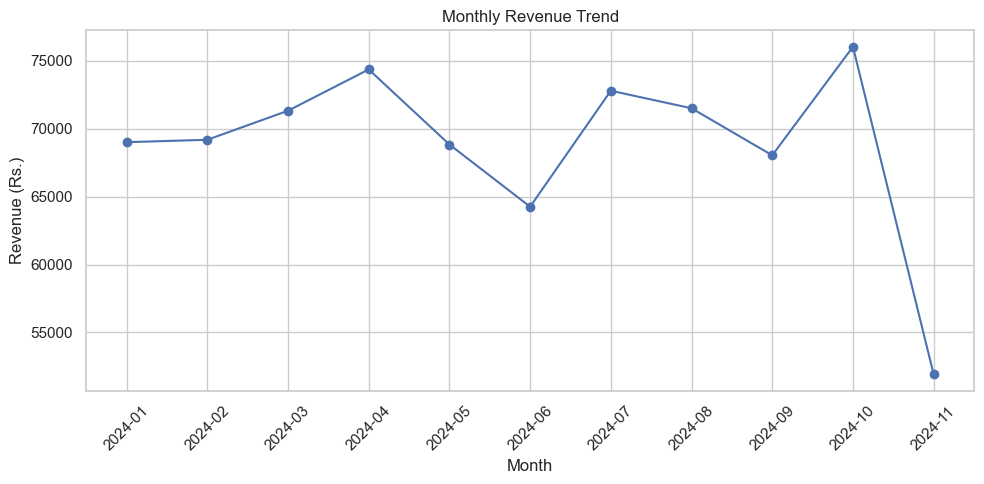

In [15]:
# Monthly revenue trend

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue["Total_Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (Rs.)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
print("Dataset columns:")
print(df.columns.tolist())

Dataset columns:
['User_ID', 'Product_ID', 'Category', 'Price (Rs.)', 'Discount (%)', 'Final_Price(Rs.)', 'Payment_Method', 'Purchase_Date']


In [17]:
customer_analysis = df.groupby("User_ID").agg(
    Purchases=("Product_ID", "count"),
    Total_Spent=("Final_Price(Rs.)", "sum"),
    Average_Purchase=("Final_Price(Rs.)", "mean")
).sort_values("Total_Spent", ascending=False)

display(customer_analysis.head(10))

,Purchases,Total_Spent,Average_Purchase
User_ID,,,
8b885340,1,496.82,496.82
20797b76,1,495.02,495.02
d8970dd2,1,493.04,493.04
da7bc76a,1,492.41,492.41
68722b9b,1,491.70,491.70
05e6557c,1,487.06,487.06
67abda0a,1,486.79,486.79
d646700c,1,484.56,484.56
edb89577,1,480.49,480.49


In [18]:
customer_frequency = df.groupby("User_ID").agg(
    Purchases=("Product_ID", "count"),
    Total_Spent=("Final_Price(Rs.)", "sum")
).sort_values("Purchases", ascending=False)

display(customer_frequency.head(10))

,Purchases,Total_Spent
User_ID,,
001ae40d,1,345.93
ae08fdb3,1,108.97
ae1b0a5d,1,84.95
ae1e6f3f,1,213.73
ae262d85,1,39.71
ae345248,1,321.91
ae5bc048,1,153.44
ae6caf94,1,177.06
ae7b7c68,1,422.70


In [19]:
customer_purchase_counts = df.groupby("User_ID")["Product_ID"].count()

repeat_customer_summary = pd.Series({
    "Total Customers": customer_purchase_counts.size,
    "One-Time Customers": (customer_purchase_counts == 1).sum(),
    "Repeat Customers": (customer_purchase_counts > 1).sum()
})

display(repeat_customer_summary)

Total Customers       3660
One-Time Customers    3660
Repeat Customers         0
dtype: int64

In [20]:
customer_spending = df.groupby("User_ID")["Final_Price(Rs.)"].sum()

print("Average customer spend:", round(customer_spending.mean(), 2))
print("Median customer spend:", round(customer_spending.median(), 2))
print("Minimum customer spend:", round(customer_spending.min(), 2))
print("Maximum customer spend:", round(customer_spending.max(), 2))

Average customer spend: 206.91
Median customer spend: 199.19
Minimum customer spend: 5.89
Maximum customer spend: 496.82


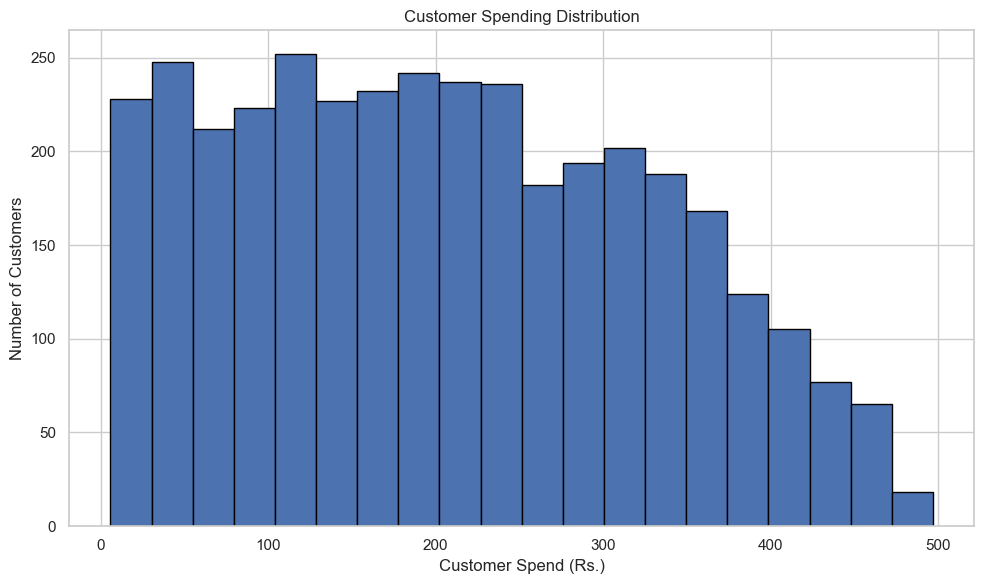

In [21]:
plt.figure(figsize=(10, 6))

plt.hist(customer_spending, bins=20, edgecolor="black")

plt.title("Customer Spending Distribution")
plt.xlabel("Customer Spend (Rs.)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [22]:
customer_segments = pd.qcut(
    customer_spending,
    q=4,
    labels=["Low Value", "Mid-Low Value", "Mid-High Value", "High Value"]
)

segment_analysis = customer_spending.groupby(
    customer_segments,
    observed=False
).agg(
    Customers="count",
    Average_Spend="mean",
    Total_Revenue="sum"
)

display(segment_analysis)

,Customers,Average_Spend,Total_Revenue
Final_Price(Rs.),,,
Low Value,915,54.722743,50071.31
Mid-Low Value,915,151.423683,138552.67
Mid-High Value,915,248.845038,227693.21
High Value,915,372.634852,340960.89


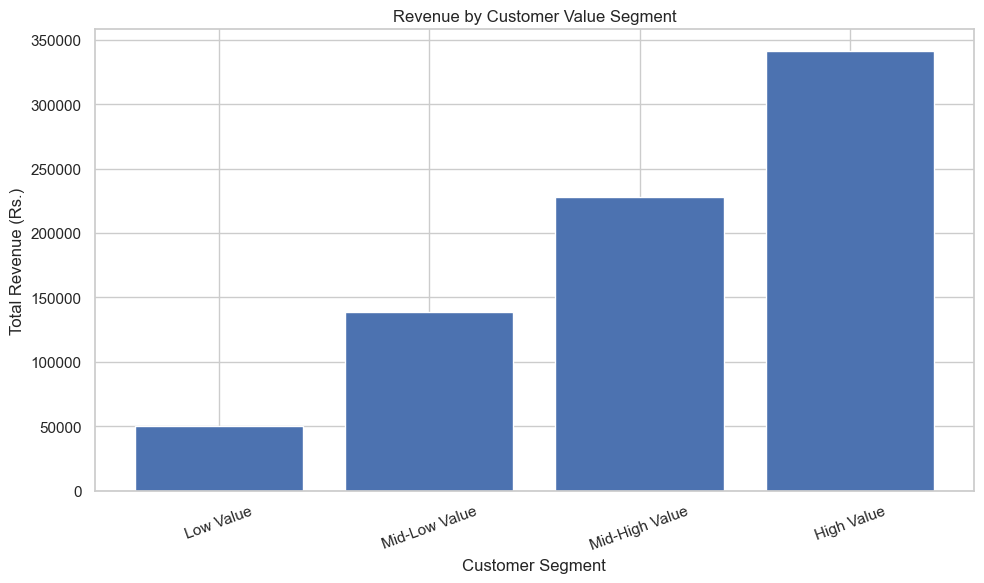

In [23]:
plt.figure(figsize=(10, 6))

plt.bar(
    segment_analysis.index,
    segment_analysis["Total_Revenue"]
)

plt.title("Revenue by Customer Value Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue (Rs.)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()